<div style="display: flex; align-items: center; justify-content: center; gap: 20px;">
    <img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcSE9HzJ3_vGCa47A_0IH_JRqOVf7O4TzeGjtA&s" alt="Image Gauche" style="width: 300px; height: auto;">
    <div style="text-align: center;">
        <h1>
            <span style="font-weight: bold; color: #00A8E0; text-decoration: underline;">
                AT&T_spam_detector
            </span>
        </h1>
    </div>
    <img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcSE9HzJ3_vGCa47A_0IH_JRqOVf7O4TzeGjtA&s" alt="Image Droite" style="width: 300px; height: auto;">
</div>


## 📚 Introduction

In this notebook, we aim to build and compare several machine learning approaches to automatically classify SMS messages as spam or ham — a crucial task for telecom providers like AT&T to protect their users from fraudulent and unwanted messages.

We implement three progressively complex and complementary methods:

1. **TF-IDF + Neural Network** – a fast and interpretable baseline using manually engineered features,  
2. **Embedding Layer + Neural Network** – a more flexible model that learns word representations from scratch,  
3. **Transfer Learning with BERT** – leveraging the power of a pre-trained transformer model for high accuracy,  

Each method will be evaluated using standard classification metrics such as accuracy, precision, and recall. Our objective is to identify the best trade-off between performance, complexity, and interpretability for spam detection.


## 0️⃣ Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Spacy for nlp
!python -m spacy download en_core_web_md -q
import en_core_web_md
from spacy.lang.en.stop_words import STOP_WORDS
nlp = en_core_web_md.load()

# sklearn functions
from sklearn.utils import resample
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score

# tensorflow functions
import tensorflow as tf 
from tensorflow import keras
from tensorflow.keras.callbacks import ModelCheckpoint
from keras.models import load_model

# Word counting
from collections import Counter

# Transformers
from transformers import AutoTokenizer
from transformers import AutoModelForSequenceClassification
from transformers import get_scheduler

# pytorch functions
import torch
from torch.utils.data import TensorDataset, DataLoader
from torch.optim import AdamW
from torch.nn import functional as F

# tqdm
from tqdm.auto import tqdm


✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')


## 1️⃣ Data retrieval and cleaning

In [2]:
# csv retrieval

dataset = pd.read_csv("modified_src/cleaned_data.csv", encoding="ISO-8859-1")

In [3]:
# Keep only alphanumeric characters, convert to lowercase, and apply lemmatization

dataset["message_clean"] = dataset["message"].apply(lambda x:''.join(ch for ch in x if ch.isalnum() or ch==" " or ch=="'"))
dataset["message_clean"] = dataset["message_clean"].apply(lambda x: x.replace(" +"," ").lower().strip())
dataset["message_clean"] = dataset["message_clean"].apply(lambda x: " ".join([token.lemma_ for token in nlp(x) if (token.lemma_ not in STOP_WORDS) and (token.text not in STOP_WORDS)]))

dataset.head()

,label,message,message_length,message_clean
0,0,"Go until jurong point, crazy.. Available only ...",111,jurong point crazy available bugis n great wor...
1,0,Ok lar... Joking wif u oni...,29,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,free entry 2 wkly comp win fa cup final tkts 2...
3,0,U dun say so early hor... U c already then say...,49,u dun early hor u c
4,0,"Nah I don't think he goes to usf, he lives aro...",61,nah think usf live


In [4]:
# Function to oversample the minority class

def data_over_sampling(data, nb_boost):
    """
    Oversample the minority class (label == '1') by duplicating its samples.

    Parameters:
        data (pd.DataFrame): The original dataset containing a 'label' column
        nb_boost (int): The oversampling factor relative to the majority class

    Returns:
        pd.DataFrame: A new dataset with oversampled minority class, shuffled
    """
    # Select majority class (label '0') and minority class (label '1')
    data_sample_1 = data.loc[data['label'] == 0, :]
    data_sample_2 = data.loc[data['label'] == 1, :]

    # Oversample the minority class with replacement
    data_sample_2 = resample(data_sample_2, 
                             replace=True,  # Sample with replacement
                             n_samples=nb_boost * len(data_sample_1), 
                             random_state=42)  # For reproducibility

    # Combine majority and oversampled minority, then shuffle
    return pd.concat([data_sample_1, data_sample_2], axis=0).sample(frac=1).reset_index(drop=True)

In [5]:
# Application on dataset_1

data_oversampled = data_over_sampling(dataset, 1)
data_oversampled['label'].value_counts()

label
0    4825
1    4825
Name: count, dtype: int64

In [6]:
# Quick visualization

data_oversampled.head()

,label,message,message_length,message_clean
0,0,Oh ! A half hour is much longer in Syria than ...,150,oh half hour long syria canada eh wow work...
1,1,URGENT! We are trying to contact U. Todays dra...,160,urgent try contact u todays draw win ãâ2000 pr...
2,0,Hey hun-onbus goin 2 meet him. He wants 2go ou...,133,hey hunonbus goin 2 meet want 2go 4a meal dony...
3,0,Babe ? I lost you ... Will you try rebooting ?,46,babe lose try reboot
4,0,Yeah I imagine he would be really gentle. Unli...,102,yeah imagine gentle unlike doc treat patient l...


## 2️⃣ TF-IDF Vectorization + Simple Neural Network


In [7]:
# Application of TfIdf

# Instantiate a TF-IDF vectorizer to convert text into numerical feature vectors
vectorizer = TfidfVectorizer()

# Fit the vectorizer on the oversampled dataset and transform the SMS messages
# This converts the text into a sparse matrix of TF-IDF scores

X = vectorizer.fit_transform(data_oversampled['message_clean'])



In [8]:
# Convert the label to a NumPy array for compatibility with model training and splitting

import numpy as np
y = np.array(data_oversampled['label'])


In [9]:
# Perform train-test-val split - 60% train, 20% val, 20% test

# Step 1: Temp (train + val) + test
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 2: Train + Val
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)


In [10]:
# Ensure input features are dense arrays, not sparse matrices

X_train = X_train.toarray()
X_val = X_val.toarray()
X_test = X_test.toarray()


In [11]:
# Definition of batch_length

batch_length=64

In [12]:
# Create TensorFlow datasets, shuffle and batch the datasets.

# Shuffling improves generalization by randomizing the order of samples
# Batching allows processing multiple samples in parallel

train = tf.data.Dataset.from_tensor_slices((X_train, y_train)).shuffle(len(X_train)).batch(batch_length)
val = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(batch_length)
test = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(batch_length)

In [13]:
# Simple Neural Network definition for binary text classification using TF-IDF features

first_model = keras.Sequential([

    # Explicit input layer: defines the shape of input data (number of TF-IDF features)
    keras.Input(shape=(X.shape[1],)),

    # First hidden layer with 128 neurons and ReLU activation function
    keras.layers.Dense(128, activation='relu'),

    # Dropout layer to reduce overfitting (randomly sets 30% of inputs to 0 during training)
    keras.layers.Dropout(0.3),

    # Second hidden layer with 64 neurons and ReLU activation
    keras.layers.Dense(64, activation='relu'),

    # Output layer with sigmoid activation to produce a probability (for binary classification)
    keras.layers.Dense(1, activation='sigmoid')
])


In [14]:
first_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │     1,038,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,047,297 (4.00 MB)

 Trainable params: 1,047,297 (4.00 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# Compile the model: use Adam optimizer and binary cross-entropy loss

first_model.compile(
    optimizer='adam',
    loss=tf.keras.losses.BinaryCrossentropy(),  # Binary classification loss
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name='accuracy'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

In [16]:
# Define a callback to save the model with the highest validation precision

checkpoint = ModelCheckpoint(
    "model_1.h5",                 # Filepath to save the model
    monitor="val_loss",           # Metric to monitor
    save_best_only=True,          # Only save model if it improves
    mode="min",                   # Because higher precision is better
    verbose=1                     # Show a message when model is saved
)

In [17]:
# Number of epochs

epochs_number = 50

In [18]:
# Train the model using the training set and validate on the validation set

history = first_model.fit(
    train,                     # Training dataset (batched and shuffled)
    validation_data=val,       # Validation dataset to monitor model performance during training
    epochs=epochs_number,      # Number of training epochs (set by the user)
    callbacks=[checkpoint],    # Callback to save the best model (based on val_loss)
    verbose=1                  # Verbose mode: 1 = progress bar for each epoch
)


Epoch 1/50
90/91 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6913 - loss: 0.5689 - precision: 0.6387 - recall: 0.9810
Epoch 1: val_loss improved from inf to 0.07398, saving model to model_1.h5


91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.6948 - loss: 0.5648 - precision: 0.6417 - recall: 0.9809 - val_accuracy: 0.9788 - val_loss: 0.0740 - val_precision: 0.9927 - val_recall: 0.9655
Epoch 2/50
86/91 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9924 - loss: 0.0350 - precision: 0.9958 - recall: 0.9890
Epoch 2: val_loss improved from 0.07398 to 0.02852, saving model to model_1.h5


91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9925 - loss: 0.0346 - precision: 0.9958 - recall: 0.9891 - val_accuracy: 0.9948 - val_loss: 0.0285 - val_precision: 0.9990 - val_recall: 0.9909
Epoch 3/50
89/91 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9988 - loss: 0.0087 - precision: 0.9986 - recall: 0.9990
Epoch 3: val_loss improved from 0.02852 to 0.02188, saving model to model_1.h5


91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9988 - loss: 0.0087 - precision: 0.9986 - recall: 0.9990 - val_accuracy: 0.9969 - val_loss: 0.0219 - val_precision: 0.9990 - val_recall: 0.9949
Epoch 4/50
84/91 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9989 - loss: 0.0052 - precision: 0.9987 - recall: 0.9990
Epoch 4: val_loss improved from 0.02188 to 0.02012, saving model to model_1.h5


91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9989 - loss: 0.0051 - precision: 0.9988 - recall: 0.9990 - val_accuracy: 0.9969 - val_loss: 0.0201 - val_precision: 0.9990 - val_recall: 0.9949
Epoch 5/50
90/91 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9999 - loss: 0.0014 - precision: 0.9998 - recall: 0.9999
Epoch 5: val_loss improved from 0.02012 to 0.01819, saving model to model_1.h5


91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9999 - loss: 0.0014 - precision: 0.9998 - recall: 0.9999 - val_accuracy: 0.9969 - val_loss: 0.0182 - val_precision: 0.9990 - val_recall: 0.9949
Epoch 6/50
84/91 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9999 - loss: 0.0011 - precision: 1.0000 - recall: 0.9999  
Epoch 6: val_loss improved from 0.01819 to 0.01710, saving model to model_1.h5


91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9999 - loss: 0.0011 - precision: 1.0000 - recall: 0.9999 - val_accuracy: 0.9979 - val_loss: 0.0171 - val_precision: 0.9990 - val_recall: 0.9970
Epoch 7/50
85/91 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 6.7119e-04 - precision: 1.0000 - recall: 1.0000
Epoch 7: val_loss did not improve from 0.01710
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 1.0000 - loss: 6.6909e-04 - precision: 1.0000 - recall: 1.0000 - val_accuracy: 0.9979 - val_loss: 0.0172 - val_precision: 0.9990 - val_recall: 0.9970
Epoch 8/50
88/91 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 4.7469e-04 - precision: 1.0000 - recall: 1.0000
Epoch 8: val_loss did not improve from 0.01710
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 1.0000 - loss: 4.7417e-04 - precision: 1.0000 - recall: 1.0000 - val_accuracy: 0.9979 - val_loss: 0.0176 - val_precision: 0.9990 - val_recall: 0.9970
Epoch 9/50
88/91 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accur

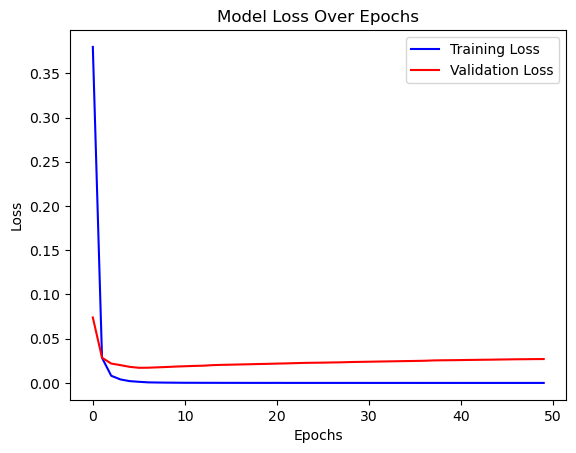

In [19]:
# Plotting the training and validation loss over epochs

plt.plot(history.history["loss"], color="b", label="Training Loss")
plt.plot(history.history["val_loss"], color="r", label="Validation Loss")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.title("Model Loss Over Epochs")
plt.legend()
plt.show()

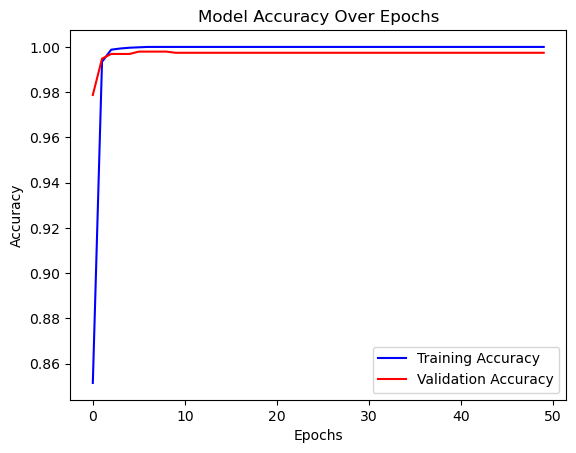

In [20]:
# Visualize accuracy over epochs

plt.plot(history.history["accuracy"], color="b", label="Training Accuracy")
plt.plot(history.history["val_accuracy"], color="r", label="Validation Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epochs")
plt.title("Model Accuracy Over Epochs")
plt.legend()
plt.show()

In [21]:
# Define a function to display the confusion matrix and key performance metrics

def display_matrix_and_scores(y_true, y_pred):
    
    print(f"Accuracy  : {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision : {precision_score(y_true, y_pred):.4f}")
    print(f"Recall    : {recall_score(y_true, y_pred):.4f}")
    ConfusionMatrixDisplay.from_predictions(y_true, y_pred)
    plt.title("Confusion Matrix")
    plt.show()
    


In [53]:
# Apply the function on test dataset

# Load the best saved model based on validation performance
best_model = load_model("model_1.h5")

# Make predictions on the test set (threshold of 0.5 for binary classification)
y_pred = (best_model.predict(X_test) > 0.5).astype("int32")

# Evaluate and display metrics
display_matrix_and_scores(y_test, y_pred)

ValueError: Exception encountered when calling Sequential.call().

[1mInput 0 of layer "dense" is incompatible with the layer: expected axis -1 of input shape to have value 8116, but received input with shape (32, 74)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(32, 74), dtype=int32)
  • training=False
  • mask=None
  • kwargs=<class 'inspect._empty'>

The model achieves excellent performance, with an accuracy of 99.7%, a precision of 99.7%, and a recall of 99.7%. The confusion matrix shows only 3 false positives and 3 false negative, confirming the robustness of the current approach. However, we will explore more advanced methods to see if further improvements are possible.

## 3️⃣ Embedding Layer + Neural Network


In [23]:
# Count words before tokenizing

# Concatenate all cleaned messages into a single text string
all_text = " ".join(data_oversampled['message_clean'])

# Split the text into individual words and count their occurrences
word_counts = Counter(all_text.split())

# Count the total number of unique words
total_unique_words = len(word_counts)
print(f"Total number of unique words: {total_unique_words}")


Total number of unique words: 8172


In [24]:
# Tokenization

# Instantiate a tokenizer that will convert words to integer sequences
# We keep all unique words (8,172 total), since the vocabulary is relatively small
# The 'oov_token' handles words not seen during training
tokenizer = tf.keras.preprocessing.text.Tokenizer(num_words=total_unique_words, oov_token="out_of_vocab")

# Fit the tokenizer on the cleaned SMS messages
tokenizer.fit_on_texts(data_oversampled['message_clean'])

# Convert the text messages to sequences of integers
data_oversampled["message_encoded"] = tokenizer.texts_to_sequences(data_oversampled['message_clean'])

In [25]:
# Pad the sequences to ensure all have the same length

# 'post' padding adds 0s at the end of sequences
message_pad = tf.keras.preprocessing.sequence.pad_sequences(data_oversampled['message_encoded'], padding="post")

# Replace the column with the padded version
data_oversampled['message_encoded'] = list(message_pad)

In [26]:
# Padding and encoding verification

data_oversampled.head()

,label,message,message_length,message_clean,message_encoded
0,0,Oh ! A half hour is much longer in Syria than ...,150,oh half hour long syria canada eh wow work...,"[159, 176, 245, 402, 4678, 3862, 1398, 676, 10..."
1,1,URGENT! We are trying to contact U. Todays dra...,160,urgent try contact u todays draw win ãâ2000 pr...,"[27, 36, 23, 2, 181, 60, 9, 80, 15, 35, 1297, ..."
2,0,Hey hun-onbus goin 2 meet him. He wants 2go ou...,133,hey hunonbus goin 2 meet want 2go 4a meal dony...,"[121, 4679, 862, 4, 119, 26, 3863, 3864, 1556,..."
3,0,Babe ? I lost you ... Will you try rebooting ?,46,babe lose try reboot,"[138, 403, 36, 3382, 0, 0, 0, 0, 0, 0, 0, 0, 0..."
4,0,Yeah I imagine he would be really gentle. Unli...,102,yeah imagine gentle unlike doc treat patient l...,"[231, 2235, 2784, 4683, 2236, 938, 4684, 38, 4..."


In [27]:
# Definition of X and y

# Convert the padded sequences column to a NumPy array for model input
X = np.array(data_oversampled['message_encoded'].tolist())

# Define the target variable y
y = np.array(data_oversampled['label'])



In [28]:
# Perform train-test-val split - 60% train, 20% val, 20% test

# Step 1: Train + Temp (val + test)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 2: Train + Val
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

In [29]:
# Definition of batch_length

batch_length=64

In [30]:
# Create TensorFlow datasets, shuffle and batch the datasets.

# Shuffling improves generalization by randomizing the order of samples
# Batching allows processing multiple samples in parallel

train = tf.data.Dataset.from_tensor_slices((X_train, y_train)).shuffle(len(X_train)).batch(batch_length)
val = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(batch_length)
test = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(batch_length)

In [31]:
# Model definition

# Define model hyperparameters
vocab_size = total_unique_words     # Number of unique tokens in the dataset
embedding_dim = 64                  # Size of the dense embedding vectors

# Determine the maximum sequence length in the padded sequences
max_length = max(len(x) for x in data_oversampled['message_encoded'])

# Define a Sequential model with an Embedding layer followed by a simple architecture
second_model = keras.Sequential([
    keras.layers.Input(shape=(max_length,)),  # Proper input definition to avoid warnings
    keras.layers.Embedding(input_dim=vocab_size, output_dim=embedding_dim),  # Word embedding layer
    keras.layers.GlobalAveragePooling1D(),    # Reduces the sequence dimension by averaging across time steps
    keras.layers.Dense(64, activation='relu'),# Fully connected layer with ReLU activation
    keras.layers.Dense(1, activation='sigmoid')  # Output layer for binary classification
])



In [32]:
second_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 74, 64)         │       523,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 527,233 (2.01 MB)

 Trainable params: 527,233 (2.01 MB)

 Non-trainable params: 0 (0.00 B)

In [33]:
# Compile the model: use Adam optimizer and binary cross-entropy loss

second_model.compile(
    optimizer='adam',
    loss=tf.keras.losses.BinaryCrossentropy(),  # Binary classification loss
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name='accuracy'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

In [34]:
# Define a callback to save the model with the highest validation precision

checkpoint = ModelCheckpoint(
    "model_2.h5",                 # Filepath to save the model
    monitor="val_loss",           # Metric to monitor
    save_best_only=True,          # Only save model if it improves
    mode="min",                   # Because higher precision is better
    verbose=1                     # Show a message when model is saved
)

In [35]:
# Number of epochs

epochs_number = 100

In [36]:
# Train the model using the training set and validate on the validation set

history = second_model.fit(
    train,                     # Training dataset (batched and shuffled)
    validation_data=val,       # Validation dataset to monitor model performance during training
    epochs=epochs_number,      # Number of training epochs (set by the user)
    callbacks=[checkpoint],    # Callback to save the best model (based on val_loss)
    verbose=1                  # Verbose mode: 1 = progress bar for each epoch
)


Epoch 1/100
78/91 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5509 - loss: 0.6839 - precision: 0.6730 - recall: 0.2046
Epoch 1: val_loss improved from inf to 0.56646, saving model to model_2.h5


91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5656 - loss: 0.6808 - precision: 0.7108 - recall: 0.2234 - val_accuracy: 0.9207 - val_loss: 0.5665 - val_precision: 0.9894 - val_recall: 0.8538
Epoch 2/100
75/91 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8591 - loss: 0.4872 - precision: 0.9650 - recall: 0.7398
Epoch 2: val_loss improved from 0.56646 to 0.25164, saving model to model_2.h5


91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8659 - loss: 0.4693 - precision: 0.9656 - recall: 0.7546 - val_accuracy: 0.9104 - val_loss: 0.2516 - val_precision: 0.9975 - val_recall: 0.8264
Epoch 3/100
79/91 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9455 - loss: 0.1904 - precision: 0.9898 - recall: 0.9012
Epoch 3: val_loss improved from 0.25164 to 0.12543, saving model to model_2.h5


91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9465 - loss: 0.1868 - precision: 0.9900 - recall: 0.9029 - val_accuracy: 0.9632 - val_loss: 0.1254 - val_precision: 0.9935 - val_recall: 0.9340
Epoch 4/100
74/91 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9698 - loss: 0.1135 - precision: 0.9928 - recall: 0.9477
Epoch 4: val_loss improved from 0.12543 to 0.09236, saving model to model_2.h5


91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9696 - loss: 0.1111 - precision: 0.9927 - recall: 0.9474 - val_accuracy: 0.9756 - val_loss: 0.0924 - val_precision: 0.9937 - val_recall: 0.9584
Epoch 5/100
77/91 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9795 - loss: 0.0708 - precision: 0.9968 - recall: 0.9614
Epoch 5: val_loss improved from 0.09236 to 0.09029, saving model to model_2.h5


...

91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9982 - loss: 0.0068 - precision: 0.9983 - recall: 0.9981 - val_accuracy: 0.9964 - val_loss: 0.0148 - val_precision: 0.9990 - val_recall: 0.9939
Epoch 24/100
75/91 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9984 - loss: 0.0060 - precision: 0.9988 - recall: 0.9979
Epoch 24: val_loss did not improve from 0.01477
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9985 - loss: 0.0059 - precision: 0.9989 - recall: 0.9980 - val_accuracy: 0.9964 - val_loss: 0.0158 - val_precision: 0.9990 - val_recall: 0.9939
Epoch 25/100
88/91 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9994 - loss: 0.0032 - precision: 0.9998 - recall: 0.9989
Epoch 25: val_loss improved from 0.01477 to 0.01409, saving model to model_2.h5


91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9994 - loss: 0.0032 - precision: 0.9998 - recall: 0.9989 - val_accuracy: 0.9964 - val_loss: 0.0141 - val_precision: 0.9990 - val_recall: 0.9939
Epoch 26/100
84/91 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9996 - loss: 0.0019 - precision: 0.9997 - recall: 0.9995  
Epoch 26: val_loss improved from 0.01409 to 0.01387, saving model to model_2.h5


91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9996 - loss: 0.0020 - precision: 0.9997 - recall: 0.9995 - val_accuracy: 0.9964 - val_loss: 0.0139 - val_precision: 0.9990 - val_recall: 0.9939
Epoch 27/100
74/91 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9989 - loss: 0.0031 - precision: 0.9998 - recall: 0.9979
Epoch 27: val_loss improved from 0.01387 to 0.01351, saving model to model_2.h5


91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9990 - loss: 0.0031 - precision: 0.9997 - recall: 0.9982 - val_accuracy: 0.9964 - val_loss: 0.0135 - val_precision: 0.9990 - val_recall: 0.9939
Epoch 28/100
88/91 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9981 - loss: 0.0076 - precision: 0.9989 - recall: 0.9974
Epoch 28: val_loss did not improve from 0.01351
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9982 - loss: 0.0075 - precision: 0.9989 - recall: 0.9974 - val_accuracy: 0.9969 - val_loss: 0.0159 - val_precision: 1.0000 - val_recall: 0.9939
Epoch 29/100
86/91 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9992 - loss: 0.0022 - precision: 0.9991 - recall: 0.9994 
Epoch 29: val_loss did not improve from 0.01351
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9992 - loss: 0.0023 - precision: 0.9991 - recall: 0.9994 - val_accuracy: 0.9953 - val_loss: 0.0174 - val_precision: 0.9939 - val_recall: 0.9970
Epoch 30/100
78/91 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.

91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 9.5443e-04 - precision: 1.0000 - recall: 1.0000 - val_accuracy: 0.9974 - val_loss: 0.0130 - val_precision: 0.9990 - val_recall: 0.9959
Epoch 84/100
83/91 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9997 - loss: 0.0011 - precision: 1.0000 - recall: 0.9995
Epoch 84: val_loss did not improve from 0.01303
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9997 - loss: 0.0011 - precision: 1.0000 - recall: 0.9995 - val_accuracy: 0.9974 - val_loss: 0.0130 - val_precision: 0.9990 - val_recall: 0.9959
Epoch 85/100
90/91 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 4.0947e-04 - precision: 1.0000 - recall: 1.0000
Epoch 85: val_loss did not improve from 0.01303
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 4.1170e-04 - precision: 1.0000 - recall: 1.0000 - val_accuracy: 0.9964 - val_loss: 0.0134 - val_precision: 0.9970 - val_recall: 0.9959
Epoch 86/100
77/91 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - a

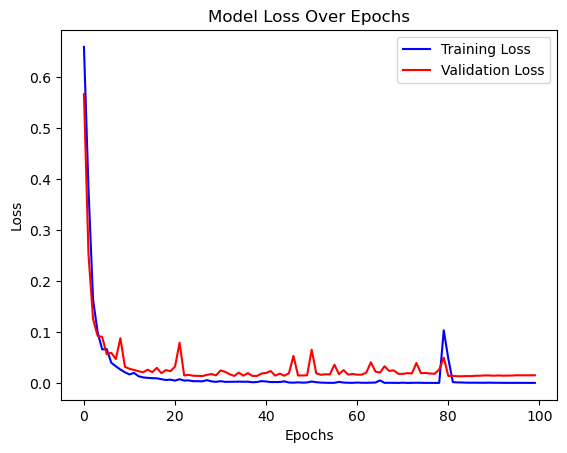

In [37]:
# Plotting the training and validation loss over epochs
plt.plot(history.history["loss"], color="b", label="Training Loss")
plt.plot(history.history["val_loss"], color="r", label="Validation Loss")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.title("Model Loss Over Epochs")
plt.legend()
plt.show()

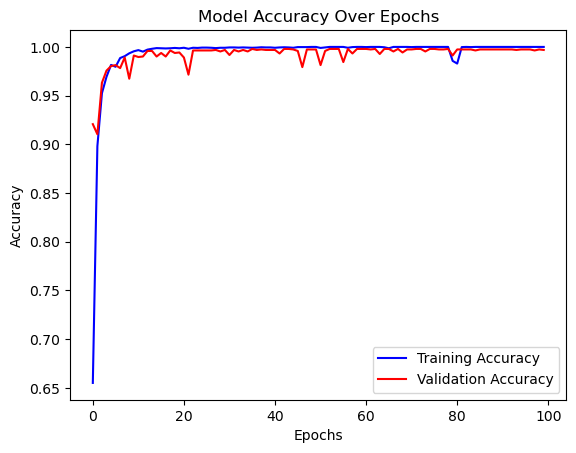

In [38]:
# Visualize accuracy over epochs

plt.plot(history.history["accuracy"], color="b", label="Training Accuracy")
plt.plot(history.history["val_accuracy"], color="r", label="Validation Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epochs")
plt.title("Model Accuracy Over Epochs")
plt.legend()
plt.show()

61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Accuracy  : 0.9959
Precision : 0.9978
Recall    : 0.9935


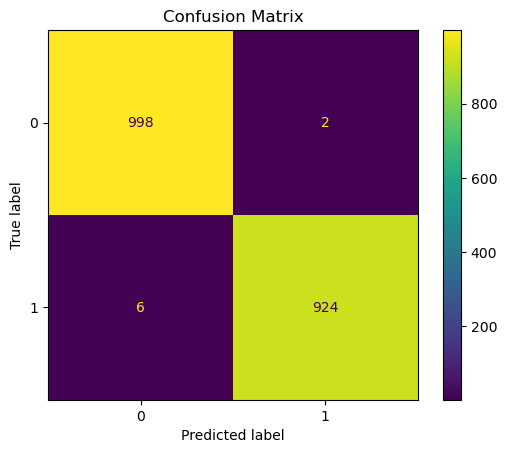

In [39]:
# Apply the function on test dataset

# Load the best saved model based on validation performance
best_model_2 = load_model("model_2.h5")

# Make predictions on the test set (threshold of 0.5 for binary classification)
y_pred = (best_model_2.predict(X_test) > 0.5).astype("int32")

# Evaluate and display metrics
display_matrix_and_scores(y_test, y_pred)

Performance remains comparable with this model, although recall is slightly lower due to an increase in false negatives. While this may be undesirable, it is generally preferable in the context of a spam detector. It is usually better to allow a few spam messages through than to incorrectly classify a legitimate email as spam.

## 4️⃣ Transfer Learning with BERT (DistilBERT)


In [40]:
# import Bert Tokenizer

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

In [41]:
# Max length

max_len = data_oversampled['message'].apply(lambda x: len(x.split())).max()

In [42]:
# Tokenizing the dataset

tokens = tokenizer(
    list(data_oversampled['message']),    # Text list
    padding=True,
    truncation=True,
    max_length=max_len,
    return_tensors='pt'              # Pour PyTorch (ou 'tf' pour TensorFlow)
)


In [43]:
# Target definition

y = torch.tensor(data_oversampled["label"].values)


In [44]:
# Train test  test split and make it ready to Pytorch

labels = y  # y is an array de 0/1 (spam/ham)

dataset_model3 = TensorDataset(
    tokens['input_ids'],
    tokens['attention_mask'],
    labels
)

train_size = int(0.6 * len(dataset_model3))
val_size = int(0.2 * len(dataset_model3))
test_size = len(dataset_model3) - train_size - val_size

train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(
    dataset_model3, [train_size, val_size, test_size]
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)
test_loader = DataLoader(test_dataset, batch_size=64)

In [45]:
# Model definition

model_3 = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased", 
    num_labels=2  # Spam / Ham = 2 classes
)


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [46]:
# Optimizer definition

optimizer = AdamW(model_3.parameters(), lr=2e-5)


In [47]:
# model visualization

print(model_3)


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSdpaAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [48]:
# Equipment evaluation

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_3.to(device)

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSdpaAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [49]:
# Epochs definition

num_epochs = 5

In [50]:
# Model training

# Scheduler

num_training_steps = num_epochs * len(train_loader)
lr_scheduler = get_scheduler("linear", optimizer=optimizer, num_warmup_steps=0, num_training_steps=num_training_steps)

# Tracking
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []
best_val_loss = float('inf')

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    
    # Training
    model_3.train()
    train_loss, correct, total = 0, 0, 0
    loop = tqdm(train_loader, desc="Training", leave=False)
    for batch in loop:
        input_ids, attn_mask, labels = [b.to(device) for b in batch]

        outputs = model_3(input_ids, attention_mask=attn_mask, labels=labels)
        loss = outputs.loss
        logits = outputs.logits

        loss.backward()
        optimizer.step()
        lr_scheduler.step()
        optimizer.zero_grad()

        train_loss += loss.item()
        preds = torch.argmax(logits, axis=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        loop.set_postfix(loss=loss.item())

    train_losses.append(train_loss / len(train_loader))
    train_accuracies.append(correct / total)

    # Validation
    model_3.eval()
    val_loss, correct, total = 0, 0, 0
    val_loop = tqdm(val_loader, desc="Validation", leave=False)
    with torch.no_grad():
        for batch in val_loop:
            input_ids, attn_mask, labels = [b.to(device) for b in batch]

            outputs = model_3(input_ids, attention_mask=attn_mask, labels=labels)
            loss = outputs.loss
            logits = outputs.logits

            val_loss += loss.item()
            preds = torch.argmax(logits, axis=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            val_loop.set_postfix(loss=loss.item())

    val_losses.append(val_loss / len(val_loader))
    val_accuracies.append(correct / total)

    tqdm.write(f"[Epoch {epoch+1}/{num_epochs}] "
           f"Train Loss: {train_losses[-1]:.4f}, Acc: {train_accuracies[-1]:.4f} | "
           f"Val Loss: {val_losses[-1]:.4f}, Acc: {val_accuracies[-1]:.4f}")


    # Save best model
    if val_losses[-1] < best_val_loss:
        torch.save(model_3.state_dict(), "model_3.h5")
        best_val_loss = val_losses[-1]



Epoch 1/5


Training:   0%|          | 0/91 [00:00<?, ?it/s]

Validation:   0%|          | 0/31 [00:00<?, ?it/s]

[Epoch 1/5] Train Loss: 0.1550, Acc: 0.9579 | Val Loss: 0.0317, Acc: 0.9886

Epoch 2/5


Training:   0%|          | 0/91 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/31 [00:00<?, ?it/s]

[Epoch 4/5] Train Loss: 0.0023, Acc: 1.0000 | Val Loss: 0.0065, Acc: 0.9984

Epoch 5/5


Training:   0%|          | 0/91 [00:00<?, ?it/s]

Validation:   0%|          | 0/31 [00:00<?, ?it/s]

[Epoch 5/5] Train Loss: 0.0018, Acc: 1.0000 | Val Loss: 0.0063, Acc: 0.9984


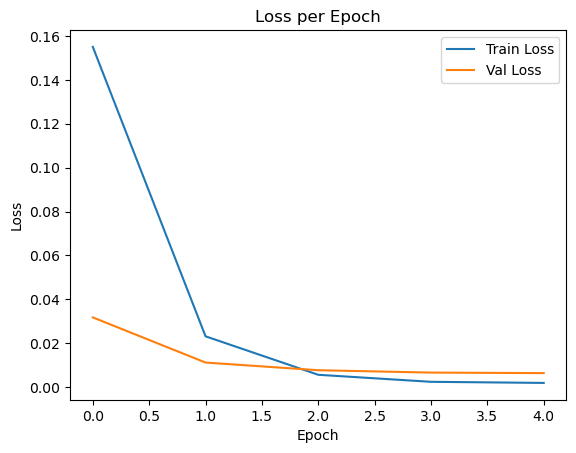

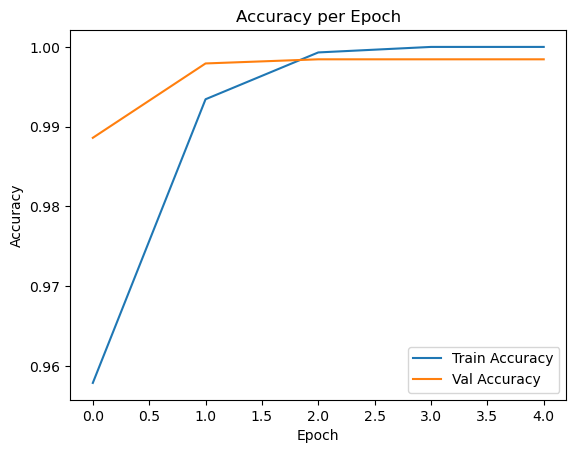

In [51]:
# losses and accuracy plots

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss per Epoch")
plt.legend()
plt.show()

plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy per Epoch")
plt.legend()
plt.show()


Accuracy  : 0.9990
Precision : 0.9979
Recall    : 1.0000


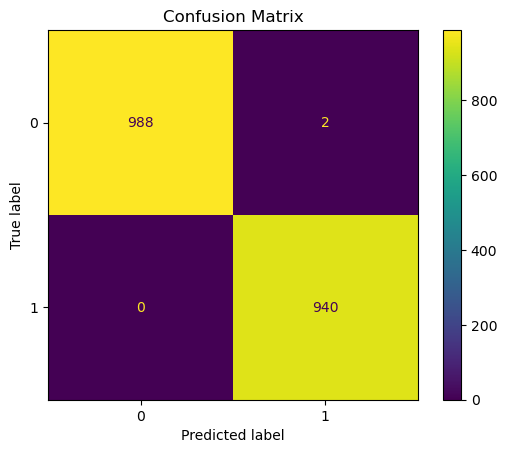

In [52]:
# Confusion matrix and scoring display


# best model loading

model_3.load_state_dict(torch.load("model_3.h5"))
model_3.eval().to(device)

# Evaluation
all_preds, all_labels = [], []

with torch.no_grad():
    for batch in test_loader: 
        input_ids, attention_mask, labels = batch
        outputs = model_3(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        preds = torch.argmax(logits, axis=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())


# Scores
print(f"Accuracy  : {accuracy_score(all_labels, all_preds):.4f}")
print(f"Precision : {precision_score(all_labels, all_preds):.4f}")
print(f"Recall    : {recall_score(all_labels, all_preds):.4f}")

# Print confusion matrix
ConfusionMatrixDisplay.from_predictions(all_labels, all_preds)
plt.title("Confusion Matrix")
plt.show()




While this model achieves slightly better performance, it comes at a significant cost in terms of size and inference speed. At 261MB, it is far heavier than the TF-IDF neural network (12MB) or the embedding-based model (6MB). For instance, generating a confusion matrix on just 2,000 emails takes several minutes. Given that the performance gains are marginal after 5 epochs, the added complexity and storage burden do not justify deploying this model in a production setting.

## 5️⃣ Conclusion

Overall, all three models demonstrate excellent performance in detecting spam messages, each achieving an accuracy, precision, and recall higher than 99.5%. 

Both the TF-IDF-based neural network and the embedding model show only 3 false positives and 3 false negatives, confirming the effectiveness and reliability of simpler approaches. While the BERT-based model provides slightly better results, the improvement is marginal and comes with significant trade-offs in terms of model size (261MB) and inference speed — making it less practical for deployment in a production environment. 

From a business perspective, the simpler models are easier to maintain, lighter to store, and fast enough for real-time applications. Therefore, given their strong performance and efficiency, they represent the most cost-effective and scalable solution for spam detection at this stage.